In [ ]:
# ==========================================================
# مشروع نظام ذكي لتشخيص أمراض أشجار الزيتون والحمضيات
# وتقديم توصيات المعالجة باستخدام التعلم العميق
#  EfficientNet-B0 & PyTorch
#
# الفصل الخامس - القسم العملي
#
# Cell (1)
# تثبيت جميع المكتبات المطلوبة
# ==========================================================
!pip install -q albumentations
!pip install -q torchmetrics
!pip install -q torchsummary
!pip install -q opencv-python
!pip install -q seaborn
!pip install -q scikit-learn

In [ ]:
# ==========================================================
# Cell (2)
# استيراد المكتبات المستخدمة في المشروع
# ==========================================================
# -------------------------
# مكتبات النظام
# -------------------------
import os
import json
import random
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")
# -------------------------
# مكتبات التعامل مع البيانات
# -------------------------
import numpy as np
import pandas as pd
# -------------------------
# مكتبات الرسم
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns
# -------------------------
# OpenCV
# -------------------------
import cv2
# -------------------------
# PyTorch
# -------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# -------------------------
# torchvision
# -------------------------
from torchvision import datasets
from torchvision import models
from torchvision.models import (efficientnet_b0, EfficientNet_B0_Weights)
# -------------------------
# Albumentations
# -------------------------
import albumentations as A
from albumentations.pytorch import ToTensorV2
# -------------------------
# مقاييس الأداء
# -------------------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print(".تم استيراد جميع المكتبات بنجاح")

.تم استيراد جميع المكتبات بنجاح


In [ ]:
# ==========================================================
# Cell (3)
# Google Drive ربط
# ==========================================================
from google.colab import drive

drive.mount('/content/drive')

print(".بنجاح Google Drive تم ربط ")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
.بنجاح Google Drive تم ربط 


In [ ]:
# ==========================================================
# Cell (4)
# تعريف مسارات المشروع
# ==========================================================
import os
# ==========================================================
# Google Drive المجلد الرئيسي داخل
# ==========================================================
PROJECT_DIR = "/content/drive/MyDrive"
# ==========================================================
# مجموعة البيانات الخام
# ==========================================================
RAW_DATASET_DIR = os.path.join( PROJECT_DIR, "raw_olive_citrus_dataset")
# ==========================================================
# مجلد حفظ النماذج
# ==========================================================
MODEL_DIR = os.path.join(PROJECT_DIR, "trained_models")
# ==========================================================
# مجلد حفظ النتائج
# ==========================================================
RESULTS_DIR = os.path.join( PROJECT_DIR, "training_results")
# ==========================================================
# إنشاء المجلدات عند الحاجة
# ==========================================================
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
# ==========================================================
# عرض المسارات
# ==========================================================
print("=" * 60)
print(".تم تعريف جميع مسارات المشروع بنجاح")
print("=" * 60)
print(f"Raw Dataset : {RAW_DATASET_DIR}")
print(f"Models      : {MODEL_DIR}")
print(f"Results     : {RESULTS_DIR}")
print("=" * 60)

.تم تعريف جميع مسارات المشروع بنجاح
Raw Dataset : /content/drive/MyDrive/raw_olive_citrus_dataset
Models      : /content/drive/MyDrive/trained_models
Results     : /content/drive/MyDrive/training_results


In [ ]:
# ==========================================================
# Cell (5)
# التأكد من وجود مجموعة البيانات
# ==========================================================
assert os.path.exists(RAW_DATASET_DIR), ".مجلد مجموعة البيانات الخام غير موجود"
print("=" * 60)
print(".تم العثور على مجموعة البيانات الخام")
print(RAW_DATASET_DIR)
print("=" * 60)

.تم العثور على مجموعة البيانات الخام
/content/drive/MyDrive/raw_olive_citrus_dataset


In [ ]:
# ==========================================================
# Cell (6)
# تعريف جهاز التنفيذ
# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ==========================================================
# Cell (7)
# تثبيت البذور العشوائية
# ==========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f".تم تثبيت البذور العشوائية بقيمة {SEED}")

.تم تثبيت البذور العشوائية بقيمة 42


In [ ]:
# ==========================================================
# Cell (8)
# قراءة أسماء الفئات من مجموعة البيانات الخام
# ==========================================================
# قراءة أسماء المجلدات الموجودة داخل مجموعة البيانات الخام
class_names = sorted([
    folder
    for folder in os.listdir(RAW_DATASET_DIR)
    if os.path.isdir(
        os.path.join(RAW_DATASET_DIR, folder))
])
# ==========================================================
# عدد الفئات
# ==========================================================
num_classes = len(class_names)
# ==========================================================
# عرض النتائج
# ==========================================================
print("=" * 60)
print(f"عدد الفئات المرضية: {num_classes}")
print("=" * 60)
for index, class_name in enumerate(class_names):
    print(f"{index:2d} --> {class_name}")

عدد الفئات المرضية: 20
 0 --> citrus_black_aphid
 1 --> citrus_black_spot
 2 --> citrus_brown_rot
 3 --> citrus_canker
 4 --> citrus_greening
 5 --> citrus_gummosis
 6 --> citrus_mealybugs
 7 --> citrus_mussel_scale
 8 --> citrus_penicillium_molds
 9 --> citrus_sooty_mold
10 --> olive_aculus_olearius
11 --> olive_anthracnose
12 --> olive_knot
13 --> olive_leopard
14 --> olive_pactrocerae
15 --> olive_prays_oleae
16 --> olive_psylle
17 --> olive_saissetia_oleae
18 --> olive_spilocaea_oleagina
19 --> olive_verticillium_wilt


In [ ]:
# ==========================================================
# Cell (9)
# إنشاء قاموس الفئات
# ==========================================================
class_to_idx = {
    class_name: index
    for index, class_name in enumerate(class_names)
}
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}
print(class_to_idx)

{'citrus_black_aphid': 0, 'citrus_black_spot': 1, 'citrus_brown_rot': 2, 'citrus_canker': 3, 'citrus_greening': 4, 'citrus_gummosis': 5, 'citrus_mealybugs': 6, 'citrus_mussel_scale': 7, 'citrus_penicillium_molds': 8, 'citrus_sooty_mold': 9, 'olive_aculus_olearius': 10, 'olive_anthracnose': 11, 'olive_knot': 12, 'olive_leopard': 13, 'olive_pactrocerae': 14, 'olive_prays_oleae': 15, 'olive_psylle': 16, 'olive_saissetia_oleae': 17, 'olive_spilocaea_oleagina': 18, 'olive_verticillium_wilt': 19}


In [ ]:
# ==========================================================
# Cell (10)
# حفظ أسماء الفئات
# ==========================================================
json_path = os.path.join(MODEL_DIR,"class_names.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(
        class_names,
        f,
        indent=4,
        ensure_ascii=False
    )
print(":تم حفظ أسماء الفئات في")
print(json_path)

:تم حفظ أسماء الفئات في
/content/drive/MyDrive/trained_models/class_names.json


In [ ]:
# ==========================================================
# Cell (11)
# حساب إحصائيات مجموعة البيانات الخام
# ==========================================================
# امتدادات الصور المدعومة
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
# ==========================================================
# حساب عدد الصور لكل مرض
# ==========================================================
dataset_statistics = []
for class_name in class_names:
    class_folder = os.path.join(RAW_DATASET_DIR, class_name)
    image_count = len([
        file
        for file in os.listdir(class_folder)
        if file.lower().endswith(image_extensions)
    ])
    dataset_statistics.append([class_name, image_count])

In [ ]:
# ==========================================================
# Cell (12)
# عرض إحصائيات مجموعة البيانات الخام
# ==========================================================
statistics_df = pd.DataFrame(dataset_statistics, columns=["Disease","Images"])
# ==========================================================
# عرض الجدول
# ==========================================================
print("=" * 60)
print("إحصائيات مجموعة البيانات الخام")
print("=" * 60)
display(statistics_df)
# ==========================================================
# الإحصائيات العامة
# ==========================================================
print("=" * 60)
print(f"عدد الأمراض: {num_classes}")
print(f"إجمالي الصور: {statistics_df['Images'].sum()}")
print(f"متوسط الصور/مرض: {statistics_df['Images'].mean():.0f}")
print(f"أقل عدد صور: {statistics_df['Images'].min()}")
print(f"أكبر عدد صور: {statistics_df['Images'].max()}")
print("=" * 60)

إحصائيات مجموعة البيانات الخام


,Disease,Images
0,citrus_black_aphid,100
1,citrus_black_spot,100
2,citrus_brown_rot,100
3,citrus_canker,100
4,citrus_greening,100
5,citrus_gummosis,100
6,citrus_mealybugs,100
7,citrus_mussel_scale,100
8,citrus_penicillium_molds,100
9,citrus_sooty_mold,100


عدد الأمراض: 20
إجمالي الصور: 2000
متوسط الصور/مرض: 100
أقل عدد صور: 100
أكبر عدد صور: 100


In [ ]:
# ==========================================================
# Cell (13)
# (Data Augmentation) إنشاء عمليات زيادة البيانات
# ==========================================================
# حجم الصورة المدخلة للنموذج
IMAGE_SIZE = 224
# ==========================================================
# تحويلات التدريب
# ==========================================================
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
# ==========================================================
# تحويلات التحقق والاختبار
# ==========================================================
valid_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
print("=" * 60)
print(".بنجاح Data Augmentation تم إنشاء عمليات")
print("=" * 60)

.بنجاح Data Augmentation تم إنشاء عمليات


In [ ]:
# ==========================================================
# Cell (14)
# قراءة جميع الصور من مجموعة البيانات الخام
# ==========================================================
# التأكد من وجود مجموعة البيانات الخام
# ==========================================================
assert os.path.exists(RAW_DATASET_DIR), ".مجلد البيانات الخام غير موجود"
# ==========================================================
# قائمة لحفظ بيانات جميع الصور
# ==========================================================
dataset = []
# ==========================================================
# المرور على جميع الفئات
# ==========================================================
for class_name in class_names:
    class_folder = os.path.join(RAW_DATASET_DIR, class_name)
    # تجاهل أي مجلد غير موجود
    if not os.path.isdir(class_folder):
        continue
    # المرور على جميع الصور
    for image_name in os.listdir(class_folder):
        if image_name.lower().endswith(
            image_extensions
        ):
            image_path = os.path.join(class_folder, image_name)
            dataset.append({"image_path": image_path, "class_name": class_name})
# ==========================================================
# DataFrame إنشاء
# ==========================================================
dataset_df = pd.DataFrame(dataset)
# ==========================================================
# التأكد من العثور على الصور
# ==========================================================
assert len(dataset_df) > 0, ".لم يتم العثور على أي صورة داخل مجموعة البيانات"
# ==========================================================
# خلط ترتيب الصور مع تثبيت البذرة العشوائية
# ==========================================================
dataset_df = dataset_df.sample(frac=1).reset_index(drop=True)
# ==========================================================
# عرض معلومات أولية
# ==========================================================
print("=" * 60)
print(".بنجاح DataFrame تم إنشاء")
print(f"إجمالي عدد الصور: {len(dataset_df)}")
print()
print(dataset_df.head())
print("=" * 60)

.بنجاح DataFrame تم إنشاء
إجمالي عدد الصور: 2000

                                          image_path                class_name
0  /content/drive/MyDrive/raw_olive_citrus_datase...  olive_spilocaea_oleagina
1  /content/drive/MyDrive/raw_olive_citrus_datase...             citrus_canker
2  /content/drive/MyDrive/raw_olive_citrus_datase...             olive_leopard
3  /content/drive/MyDrive/raw_olive_citrus_datase...         citrus_sooty_mold
4  /content/drive/MyDrive/raw_olive_citrus_datase...                olive_knot


In [ ]:
# ==========================================================
# Cell (15)
# التقسيم الطبقي للبيانات
# Stratified Train / Validation / Test Split
# ==========================================================
from sklearn.model_selection import train_test_split
# ==========================================================
# المرحلة الأولى
# 70% تدريب
# 30% بيانات مؤقتة
# ==========================================================
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df["class_name"],
    shuffle=True
)
# ==========================================================
# المرحلة الثانية
# 15% Validation
# 15% Test
# ==========================================================
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    shuffle=True
)
# ==========================================================
# إعادة ترتيب الفهارس
# ==========================================================
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
# ==========================================================
# التأكد من عدم فقدان أي صورة
# ==========================================================
assert (len(train_df) + len(val_df) + len(test_df)) == len(dataset_df), ".حدث خطأ أثناء تقسيم البيانات"
# ==========================================================
# عدد الصور لكل فئة
# ==========================================================
summary_df = pd.DataFrame({
    "Train": train_df["class_name"].value_counts().sort_index(),
    "Validation": val_df["class_name"].value_counts().sort_index(),
    "Test": test_df["class_name"].value_counts().sort_index()
})
summary_df["Total"] = summary_df.sum(axis=1)
# ==========================================================
# التأكد من أن كل فئة تحتوي على 100 صورة
# ==========================================================
assert (summary_df["Total"] == 100).all(), ".بعض الفئات لا تحتوي على 100 صورة"
# ==========================================================
# عرض نتائج التقسيم
# ==========================================================
print("=" * 60)
print("تم تقسيم البيانات بنجاح.")
print("=" * 60)
print(f"عدد صور التدريب: {len(train_df)}")
print(f"عدد صور التحقق: {len(val_df)}")
print(f"عدد صور الاختبار: {len(test_df)}")
print("=" * 60)
print()
print("عدد الصور لكل فئة")
print("=" * 60)
display(summary_df)

تم تقسيم البيانات بنجاح.
عدد صور التدريب: 1400
عدد صور التحقق: 300
عدد صور الاختبار: 300

عدد الصور لكل فئة


,Train,Validation,Test,Total
class_name,,,,
citrus_black_aphid,70,15,15,100
citrus_black_spot,70,15,15,100
citrus_brown_rot,70,15,15,100
citrus_canker,70,15,15,100
citrus_greening,70,15,15,100
citrus_gummosis,70,15,15,100
citrus_mealybugs,70,15,15,100
citrus_mussel_scale,70,15,15,100
citrus_penicillium_molds,70,15,15,100


In [ ]:
# ==========================================================
# Cell (16)
# مخصص Dataset إنشاء
#==========================================================
from torch.utils.data import Dataset
# ==========================================================
# مخصص لمجموعة البيانات Dataset
# ==========================================================
class PlantDiseaseDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    # ------------------------------------------------------
    def __len__(self):
        return len(self.dataframe)
    # ------------------------------------------------------
    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "class_name"]
        label = class_to_idx[label_name]
        # قراءة الصورة
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # تطبيق التحويلات
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label, image_path

In [ ]:
# ==========================================================
# Cell (17)
# إنشاء مجموعات التدريب والتحقق والاختبار
# ==========================================================
# Datasets إنشاء الـ
# ==========================================================
train_dataset = PlantDiseaseDataset(dataframe=train_df, transform=train_transform)
val_dataset = PlantDiseaseDataset(dataframe=val_df, transform=valid_transform)
test_dataset = PlantDiseaseDataset(dataframe=test_df, transform=valid_transform)
# ==========================================================
# عرض عدد الصور
# ==========================================================
print("=" * 60)
print(".تم إنشاء مجموعات البيانات بنجاح")
print()
print(f"Train Dataset : {len(train_dataset)}")
print(f"Validation Dataset : {len(val_dataset)}")
print(f"Test Dataset : {len(test_dataset)}")
print("=" * 60)

.تم إنشاء مجموعات البيانات بنجاح

Train Dataset : 1400
Validation Dataset : 300
Test Dataset : 300


In [ ]:
# ==========================================================
# Cell (18)
# DataLoaders إنشاء
# ==========================================================
from torch.utils.data import DataLoader
# ==========================================================
# إعدادات التحميل
# ==========================================================
BATCH_SIZE = 16
NUM_WORKERS = 2
# ==========================================================
# لمجموعة التدريب DataLoader
# ==========================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
# ==========================================================
# لمجموعة التحقق DataLoader
# ==========================================================
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
# ==========================================================
# لمجموعة الاختبار DataLoader
# ==========================================================
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
# ==========================================================
# عرض معلومات التحميل
# ==========================================================
print("=" * 60)
print(" بنجاح DataLoaders تم إنشاء")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Num Workers: {NUM_WORKERS}")
print("=" * 60)

 بنجاح DataLoaders تم إنشاء
Batch Size: 16
Num Workers: 2


In [ ]:
# ==========================================================
# Cell (19)
# DataLoader  اختبار الـ
# ==========================================================
images, labels, image_paths = next(iter(train_loader))
print("=" * 60)
print(" DataLoader اختبار الـ")
print("=" * 60)
print(f"Batch Shape : {images.shape}")
print(f"Labels Shape: {labels.shape}")
print(f"First Image : {image_paths[0]}")
print("=" * 60)

 DataLoader اختبار الـ
Batch Shape : torch.Size([16, 3, 224, 224])
Labels Shape: torch.Size([16])
First Image : /content/drive/MyDrive/raw_olive_citrus_dataset/citrus_sooty_mold/citrus_sooty_mold_086.jpg


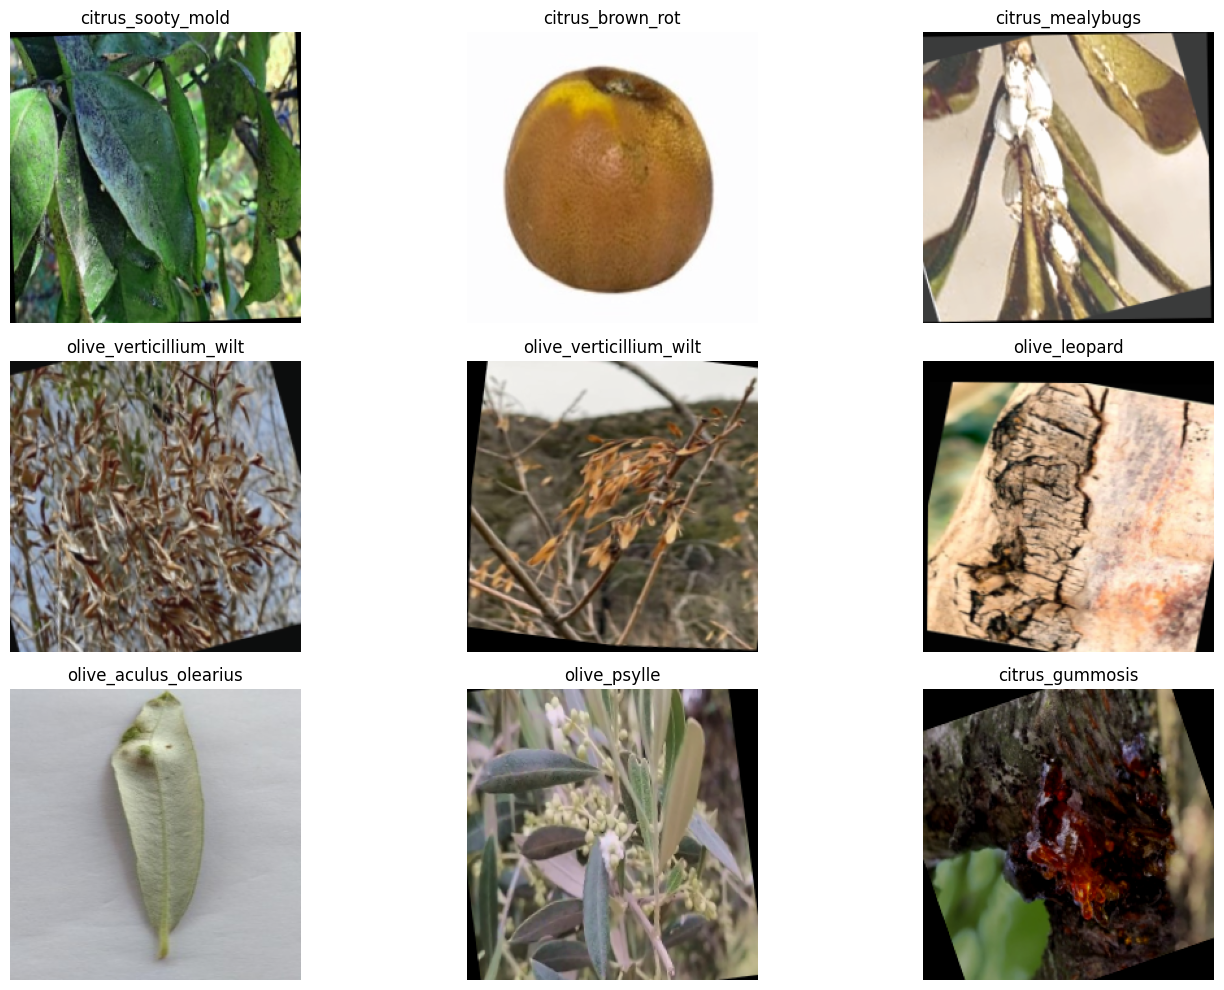

In [ ]:
# ==========================================================
# Cell (20)
# Data Augmentation عرض صور بعد عمليات زيادة البيانات
# ==========================================================
plt.figure(figsize=(15, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # NumPy إلى Tensor تحويل الصورة من
    image = images[i].permute(1, 2, 0).cpu().numpy()
    # إزالة التطبيع لغرض العرض
    image = (image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    image = np.clip(image, 0, 1)
    plt.imshow(image)
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Cell (21)
# EfficientNet-B0 إنشاء نموذج
# ==========================================================
import torch
import torch.nn as nn
from torchvision import models
# ==========================================================
# ImageNet المدرب مسبقاً على EfficientNet-B0 تحميل نموذج
# ==========================================================
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
# ==========================================================
# عدد الميزات الداخلة إلى طبقة التصنيف الأخيرة
# ==========================================================
num_features = model.classifier[1].in_features
# ==========================================================
# استبدال طبقة التصنيف الأخيرة
# ==========================================================
model.classifier[1] = nn.Linear(num_features, num_classes)
# ==========================================================
# نقل النموذج إلى الجهاز
# ==========================================================
model = model.to(device)
# ==========================================================
# عرض معلومات النموذج
# ==========================================================
print("=" * 60)
print(".بنجاح EfficientNet-B0 تم إنشاء نموذج")
print(f"عدد الفئات: {num_classes}")
print(f"عدد الميزات الداخلة: {num_features}")
print("=" * 60)

.بنجاح EfficientNet-B0 تم إنشاء نموذج
عدد الفئات: 20
عدد الميزات الداخلة: 1280


In [ ]:
# ==========================================================
# Cell (22)
# EfficientNet-B0 إظهار بنية نموذج
# ==========================================================
print(model)

In [ ]:
# ==========================================================
# Cell (23)
# إعداد عملية التدريب
# ==========================================================
import torch.nn as nn
import torch.optim as optim
# ==========================================================
# (Loss Function) دالة الخطأ
# ==========================================================
criterion = nn.CrossEntropyLoss()
# ==========================================================
# (Adam Optimizer) المحسن
# ==========================================================
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# ==========================================================
# (Learning Rate Scheduler) مخفض معدل التعلم
# ==========================================================
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
    factor=0.5, patience=3)
# ==========================================================
# عدد دورات التدريب
# ==========================================================
num_epochs = 20
# ==========================================================
# عرض إعدادات التدريب
# ==========================================================
print("=" * 60)
print(".تم إعداد عملية التدريب بنجاح")
print("=" * 60)
print(f"Loss Function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"Weight Decay: {optimizer.param_groups[0]['weight_decay']}")
print(f"Epochs: {num_epochs}")
print("=" * 60)

.تم إعداد عملية التدريب بنجاح
Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.0001
Weight Decay: 0.0001
Epochs: 20


In [ ]:
# ==========================================================
# Cell (24)
# (Training Loop) حلقة تدريب النموذج
# ==========================================================
import copy
import time
# ==========================================================
# وقت بداية التدريب
# ==========================================================
start_time = time.time()
# ==========================================================
# أفضل دقة تحقق
# ==========================================================
best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
# ==========================================================
# قوائم حفظ نتائج التدريب
# ==========================================================
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
# ==========================================================
# Early Stopping إعدادات التوقف المبكر
# ==========================================================
patience = 5
early_stop_counter = 0
# ==========================================================
# مسار حفظ أفضل نموذج
# ==========================================================
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnet_b0_stratified_best.pth")
# ==========================================================
# بدء التدريب
# ==========================================================
for epoch in range(num_epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("=" * 60)
    # ======================================================
    # وضع التدريب
    # ======================================================
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0
    # ======================================================
    # التدريب
    # ======================================================
    for images, labels, image_paths in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
    # ======================================================
    # نتائج التدريب
    # ======================================================
    train_loss = running_loss / total_samples
    train_accuracy = running_correct / total_samples
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    # ======================================================
    # مرحلة التحقق
    # ======================================================
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_samples = 0
    with torch.no_grad():
        for images, labels, image_paths in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += (loss.item() * images.size(0))
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_samples += labels.size(0)
    val_loss = val_running_loss / val_samples
    val_accuracy = val_correct / val_samples
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    # ======================================================
    # Learning Rate تحديث معدل التعلم
    # ======================================================
    scheduler.step(val_accuracy)
    # ======================================================
    # حفظ أفضل نموذج
    # ======================================================
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        early_stop_counter = 0
        print(".تم حفظ أفضل نموذج")
    else:
        early_stop_counter += 1
    # ======================================================
    # طباعة النتائج
    # ======================================================
    print(f"Training Loss       : {train_loss:.4f}")
    print(f"Training Accuracy   : {train_accuracy:.4f}")
    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_accuracy:.4f}")
    print(f"Early Stop Counter  : {early_stop_counter}/{patience}")
    # ======================================================
    # Early Stopping التحقق من التوقف المبكر
    # ======================================================
    if early_stop_counter >= patience:
        print()
        print("=" * 60)
        print("تم إيقاف التدريب مبكراً (Early Stopping).")
        print("=" * 60)
        break
# ==========================================================
# تحميل أفضل نموذج
# ==========================================================
model.load_state_dict(best_model_weights)
# ==========================================================
# زمن التدريب
# ==========================================================
elapsed_time = time.time() - start_time
print()
print("=" * 60)
print(".انتهى التدريب بنجاح")
print(f"أفضل Validation Accuracy: {best_val_accuracy:.4f}")
print(f"زمن التدريب: {elapsed_time / 60:.2f} دقيقة")
print()
print(":تم حفظ أفضل نموذج في")
print(BEST_MODEL_PATH)
print("=" * 60)

Epoch 1/20
.تم حفظ أفضل نموذج
Training Loss       : 2.5830
Training Accuracy   : 0.3407
Validation Loss     : 1.8944
Validation Accuracy : 0.6533
Early Stop Counter  : 0/5
Epoch 2/20
.تم حفظ أفضل نموذج
Training Loss       : 1.5142
Training Accuracy   : 0.7143
Validation Loss     : 0.9052
Validation Accuracy : 0.8400
Early Stop Counter  : 0/5
Epoch 3/20
.تم حفظ أفضل نموذج
Training Loss       : 0.8213
Training Accuracy   : 0.8286
Validation Loss     : 0.4896
Validation Accuracy : 0.8867
Early Stop Counter  : 0/5
Epoch 4/20
.تم حفظ أفضل نموذج
Training Loss       : 0.5016
Training Accuracy   : 0.8950
Validation Loss     : 0.3351
Validation Accuracy : 0.9267
Early Stop Counter  : 0/5
Epoch 5/20
.تم حفظ أفضل نموذج
Training Loss       : 0.3397
Training Accuracy   : 0.9250
Validation Loss     : 0.2434
Validation Accuracy : 0.9300
Early Stop Counter  : 0/5
Epoch 6/20
.تم حفظ أفضل نموذج
Training Loss       : 0.2574
Training Accuracy   : 0.9414
Validation Loss     : 0.2105
Validation Accuracy : 0

In [ ]:
# ==========================================================
# Cell (25)
# تقييم النموذج على مجموعة الاختبار
# Evaluation on Test Dataset
# ==========================================================
import torch
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
# ==========================================================
# وضع النموذج في نمط التقييم
# ==========================================================
model.eval()
# ==========================================================
# قوائم حفظ النتائج
# ==========================================================
true_labels = []
predicted_labels = []
prediction_scores = []
all_probabilities = []
image_paths = []
# ==========================================================
# تنفيذ الاختبار
# ==========================================================
with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, dim=1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())
        prediction_scores.extend(confidences.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        image_paths.extend(paths)
# ==========================================================
# NumPy Arrays تحويل النتائج إلى
# ==========================================================
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)
prediction_scores = np.array(prediction_scores)
all_probabilities = np.array(all_probabilities)
# ==========================================================
# حساب المقاييس العامة
# ==========================================================
test_accuracy = accuracy_score(true_labels, predicted_labels)
test_precision = precision_score(true_labels, predicted_labels, average="weighted")
test_recall = recall_score(true_labels, predicted_labels, average="weighted")
test_f1 = f1_score(true_labels, predicted_labels, average="weighted")
# ==========================================================
# عرض النتائج
# ==========================================================
print("=" * 60)
print("نتائج الاختبار النهائية")
print("=" * 60)
print(f"عدد صور الاختبار: {len(true_labels)}")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print("=" * 60)
# ==========================================================
# التحقق من أبعاد البيانات
# ==========================================================
print()
print("تم حفظ البيانات التالية:")
print(f"True Labels       : {true_labels.shape}")
print(f"Predicted Labels  : {predicted_labels.shape}")
print(f"Prediction Scores : {prediction_scores.shape}")
print(f"All Probabilities : {all_probabilities.shape}")
print("=" * 60)

نتائج الاختبار النهائية
عدد صور الاختبار: 300
Accuracy : 0.9567
Precision: 0.9597
Recall   : 0.9567
F1 Score : 0.9568

تم حفظ البيانات التالية:
True Labels       : (300,)
Predicted Labels  : (300,)
Prediction Scores : (300,)
All Probabilities : (300, 20)


In [ ]:
# ==========================================================
# Cell (26)
# Classification Report
# ==========================================================
from sklearn.metrics import classification_report
print("=" * 70)
print("Classification Report")
print("=" * 70)
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4,
    zero_division=0
)
print(report)
print("=" * 70)

Classification Report
                          precision    recall  f1-score   support

      citrus_black_aphid     1.0000    0.9333    0.9655        15
       citrus_black_spot     0.8824    1.0000    0.9375        15
        citrus_brown_rot     1.0000    0.8667    0.9286        15
           citrus_canker     1.0000    1.0000    1.0000        15
         citrus_greening     1.0000    1.0000    1.0000        15
         citrus_gummosis     1.0000    0.9333    0.9655        15
        citrus_mealybugs     0.9333    0.9333    0.9333        15
     citrus_mussel_scale     0.9333    0.9333    0.9333        15
citrus_penicillium_molds     1.0000    1.0000    1.0000        15
       citrus_sooty_mold     0.9375    1.0000    0.9677        15
   olive_aculus_olearius     0.9333    0.9333    0.9333        15
       olive_anthracnose     0.9375    1.0000    0.9677        15
              olive_knot     0.9375    1.0000    0.9677        15
           olive_leopard     1.0000    0.9333    0.96

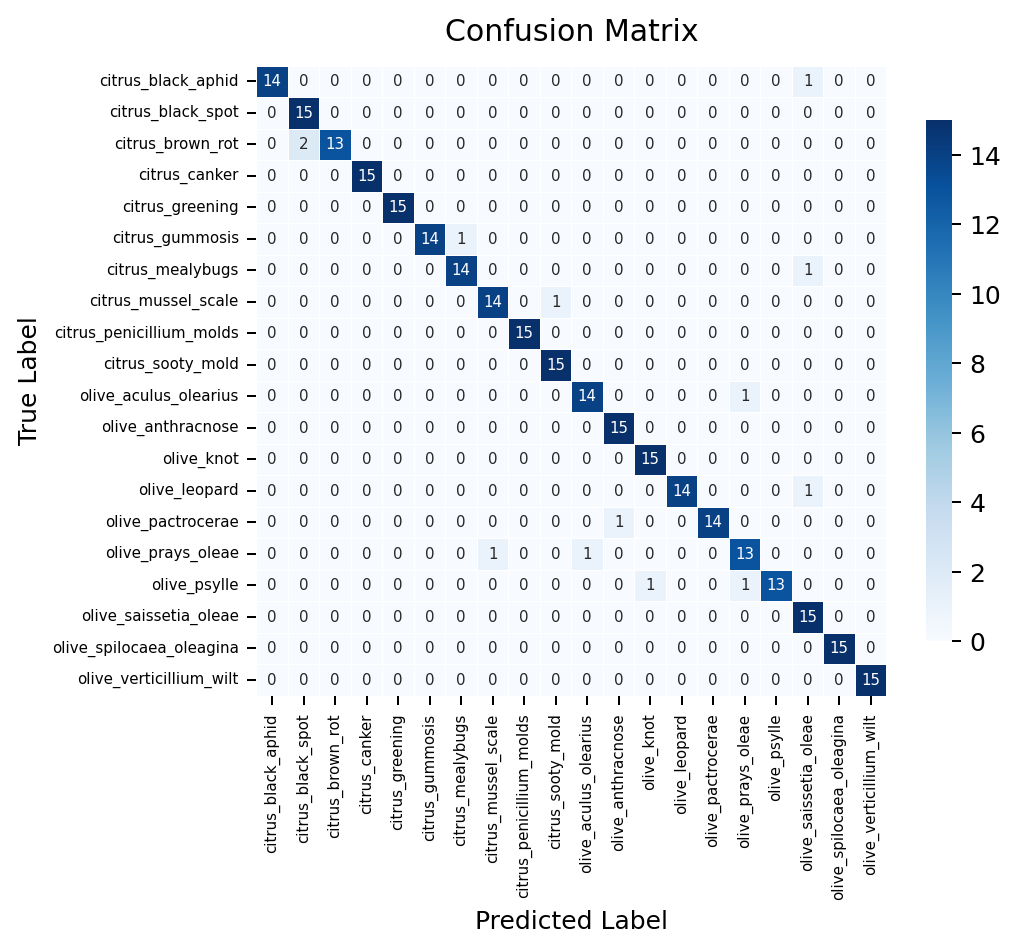

In [ ]:
# ==========================================================
# Cell (27)
# رسم مصفوفة الارتباك
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# ==========================================================
# حساب مصفوفة الارتباك
# ==========================================================
cm = confusion_matrix(true_labels, predicted_labels)
# ==========================================================
# رسم المصفوفة
# ==========================================================
plt.figure(figsize=(6, 6), dpi=180)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.4,
    cbar=True,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 6},
    cbar_kws={"shrink": 0.60}
)
plt.title("Confusion Matrix", fontsize=12, pad=10)
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("True Label", fontsize=10)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Cell (28)
# جدول أداء كل مرض
# ==========================================================
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
# ==========================================================
# لكل مرض F1 و Recall و Precision حساب
# ==========================================================
precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average=None,
    zero_division=0
)
# ==========================================================
# إنشاء الجدول
# ==========================================================
results = pd.DataFrame({
    "Disease": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Support": support
})
# ==========================================================
# تقريب القيم
# ==========================================================
results["Precision"] = results["Precision"].round(4)
results["Recall"] = results["Recall"].round(4)
results["F1 Score"] = results["F1 Score"].round(4)
# ==========================================================
# ترتيب الجدول حسب F1 Score
# ==========================================================
results = results.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
# ==========================================================
# إضافة ترتيب الأمراض
# ==========================================================
results.insert(0, "Rank", range(1, len(results) + 1))
# ==========================================================
# عرض الجدول
# ==========================================================
display(results)

,Rank,Disease,Precision,Recall,F1 Score,Support
0,1,citrus_canker,1.0000,1.0000,1.0000,15
1,2,olive_verticillium_wilt,1.0000,1.0000,1.0000,15
2,3,citrus_penicillium_molds,1.0000,1.0000,1.0000,15
3,4,citrus_greening,1.0000,1.0000,1.0000,15
4,5,olive_spilocaea_oleagina,1.0000,1.0000,1.0000,15
5,6,citrus_sooty_mold,0.9375,1.0000,0.9677,15
6,7,olive_anthracnose,0.9375,1.0000,0.9677,15
7,8,olive_knot,0.9375,1.0000,0.9677,15
8,9,olive_pactrocerae,1.0000,0.9333,0.9655,15
9,10,olive_leopard,1.0000,0.9333,0.9655,15


In [ ]:
# ==========================================================
# Cell (30)
# عرض الصور التي أخطأ النموذج في تصنيفها
# ==========================================================
import random
import cv2
import matplotlib.pyplot as plt
# ==========================================================
# تثبيت البذرة العشوائية
# ==========================================================
#random.seed(SEED)
# ==========================================================
# البحث عن الصور التي أخطأ النموذج في تصنيفها
# ==========================================================
errors = []
for i in range(len(true_labels)):
    if true_labels[i] != predicted_labels[i]:
        errors.append(i)
# ==========================================================
# التحقق من وجود أخطاء
# ==========================================================
if len(errors) == 0:
    print("=" * 60)
    print("لا توجد صور مصنفة بشكل خاطئ.")
    print("=" * 60)
else:
    # اختيار 16 صورة عشوائياً
    random.shuffle(errors)
    errors = errors[:16]
    # ======================================================
    # رسم الصور
    # ======================================================
    plt.figure(figsize=(14, 14), dpi=180)
    for i, index in enumerate(errors):
        image = cv2.imread(image_paths[index])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(4, 4, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"True : {class_names[true_labels[index]]}\n"
            f"Pred : {class_names[predicted_labels[index]]}\n"
            f"Confidence : {prediction_scores[index] * 100:.1f}%",
            fontsize=8
        )
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================================
# Cell (31)
# Excel و CSV  حفظ نتائج الاختبار في ملفات
# ==========================================================
import os
import pandas as pd
# ==========================================================
# إنشاء جدول النتائج
# ==========================================================
results_df = pd.DataFrame({
    "Image Path": image_paths,
    "True Label": [
        class_names[x]
        for x in true_labels
    ],
    "Predicted Label": [
        class_names[x]
        for x in predicted_labels
    ],
    "Confidence (%)": (
        prediction_scores * 100
    ).round(2)
})
# ==========================================================
# مسارات الحفظ
# ==========================================================
csv_path = os.path.join(RESULTS_DIR, "efficientnet_b0_stratified_results.csv")
excel_path = os.path.join(RESULTS_DIR, "efficientnet_b0_stratified_results.xlsx")
# ==========================================================
# حفظ النتائج
# ==========================================================
results_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
results_df.to_excel(excel_path, index=False)
# ==========================================================
# عرض رسالة النجاح
# ==========================================================
print("=" * 60)
print(".تم حفظ النتائج بنجاح")
print()
print("CSV File:")
print(csv_path)
print()
print("Excel File:")
print(excel_path)
print("=" * 60)

.تم حفظ النتائج بنجاح

CSV File:
/content/drive/MyDrive/training_results/efficientnet_b0_stratified_results.csv

Excel File:
/content/drive/MyDrive/training_results/efficientnet_b0_stratified_results.xlsx


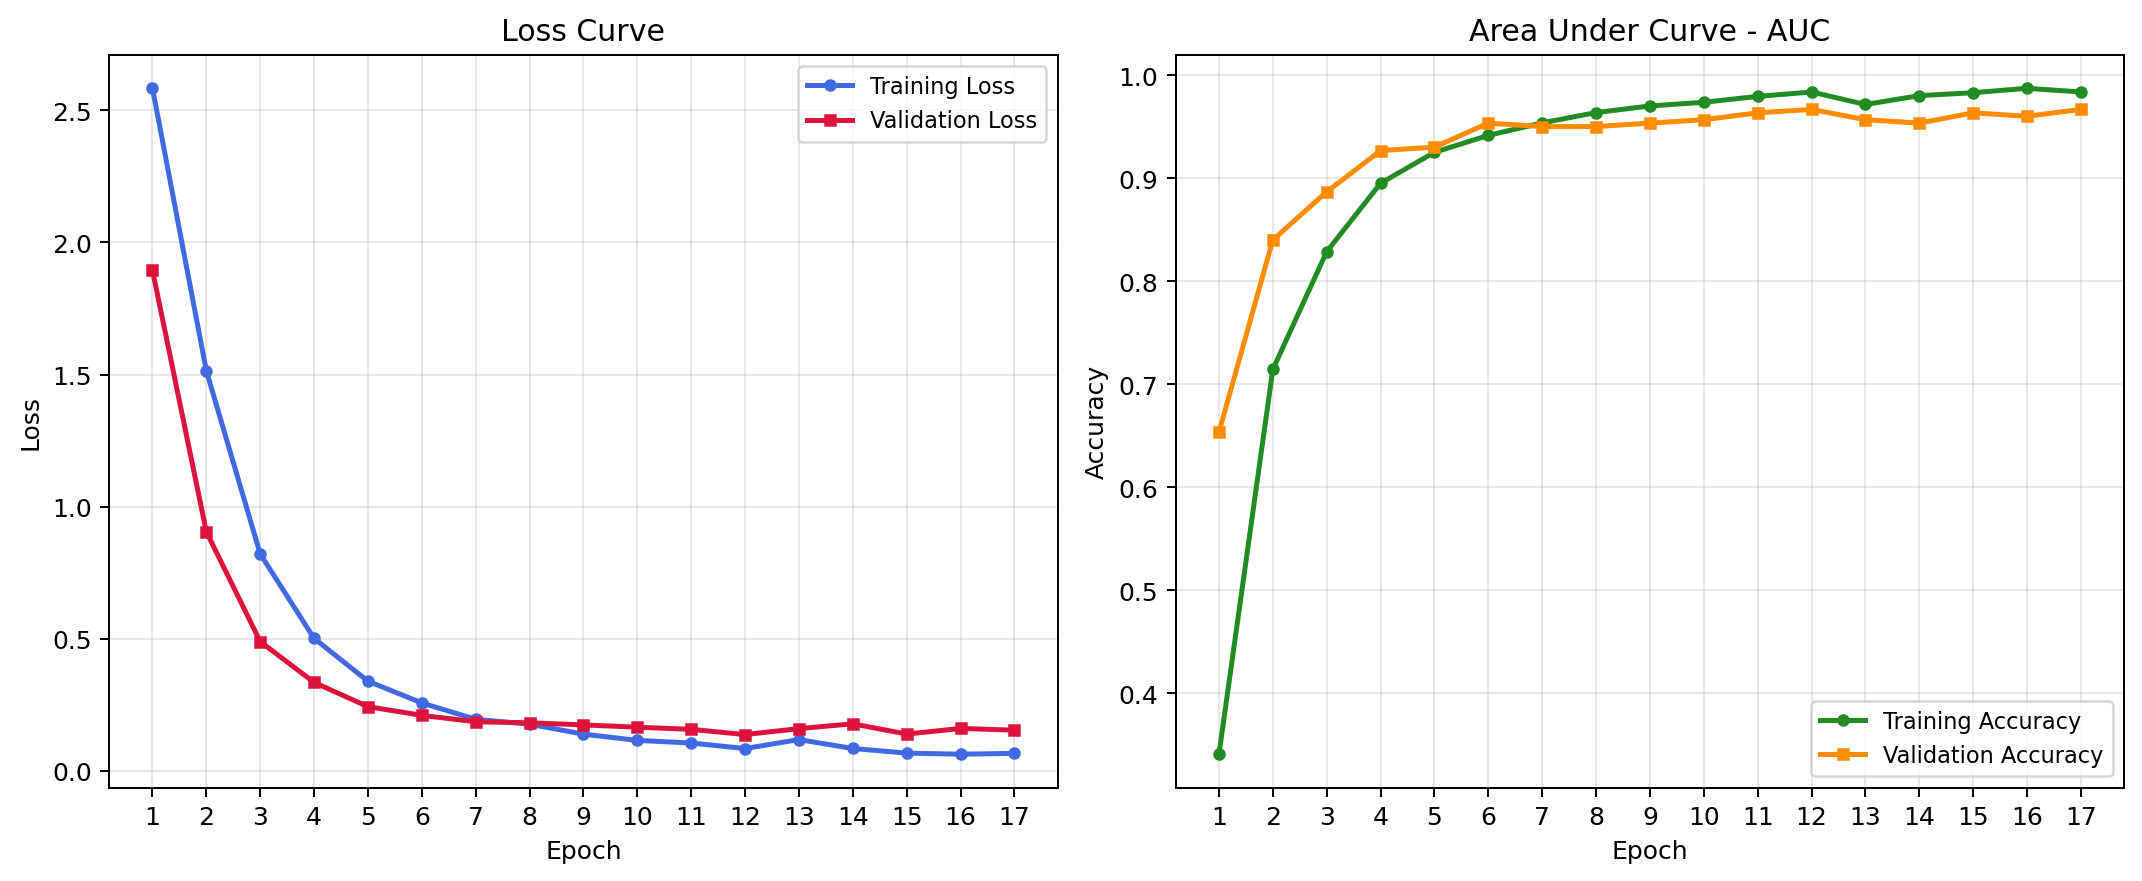

In [ ]:
# ==========================================================
# Cell (32)
# رسم منحنيات التدريب
# Training History Curves
# ==========================================================
import matplotlib.pyplot as plt
# ==========================================================
# Epochs أرقام الـ
# ==========================================================
epochs = range(1, len(train_losses) + 1)
# ==========================================================
# إنشاء الشكل
# ==========================================================
plt.figure(figsize=(12,5), dpi=180)
# ==========================================================
# Loss رسم منحنيات الخسارة لبيانات التدريب والتحقق
# ==========================================================
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, color="royalblue",
         linewidth=2, marker="o", markersize=4, label="Training Loss")
plt.plot(epochs, val_losses, color="crimson",
         linewidth=2, marker="s", markersize=4, label="Validation Loss")
plt.title("Loss Curve", fontsize=12)
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("Loss", fontsize=10)
# فقط Epoch عرض أرقام الـ
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
# ==========================================================
# Accuracy رسم منحنيات الدقة لبيانات التدريب والتحقق
# ==========================================================
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, color="forestgreen",
         linewidth=2, marker="o", markersize=4, label="Training Accuracy")
plt.plot(epochs, val_accuracies, color="darkorange",
         linewidth=2, marker="s", markersize=4, label="Validation Accuracy")
plt.title("Area Under Curve - AUC", fontsize=12)
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("Accuracy", fontsize=10)
# فقط Epoch عرض أرقام الـ
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
# ==========================================================
# عرض الشكل
# ==========================================================
plt.tight_layout()
plt.show()